In [1]:
import scipy.io
import numpy as np
from mfpy import SegmentBasedCluster
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import ot
import pydub
import simpleaudio
from math import floor
from IPython.display import Audio, display

In [2]:
data = scipy.io.loadmat("Start-241-14-30-35.mat")
data['TimeSeries'].shape

(1, 41943040)

In [3]:
fs = floor(data['Fs'].item())
n_samples = 9 * 4
t_deep = data['t_deep'].flatten()
t_shallow = data['t_shallow'].flatten()
t0_sec = 1.7375#t_deep[0]
t0_samp = fs*t0_sec
t0 = floor(t0_samp)
w=512
fs, w/fs

(11718, 0.04369346304830176)

In [7]:
(941 * 512) / fs

41.115548728451955

In [8]:
ts = np.trunc(fs * data['t_deep'][0][:n_samples]).astype(int)
Y = data['TimeSeries'].T[t0:t0 + np.trunc(n_samples*fs).astype(int),0].flatten()
Y.shape

(421848,)

((257,), (941,), (257, 941))

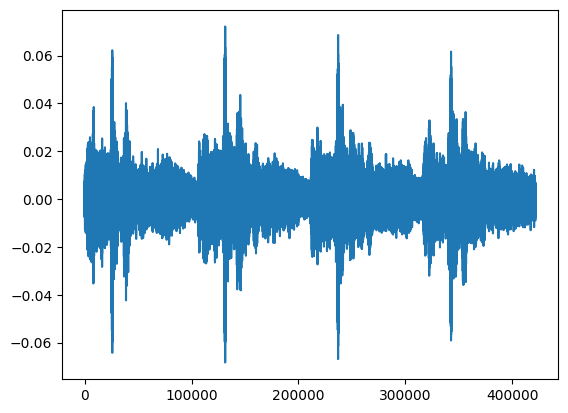

In [ ]:
audio = Audio(data=Y, rate=int(fs))
display(audio)

fig, ax = plt.subplots()
plt.plot(Y)

f, t, Sxx = scipy.signal.spectrogram(
    Y,
    fs,
    nperseg=w
)

distributions = Sxx / Sxx.sum(axis=0, keepdims=True)
f.shape, t.shape, Sxx.shape

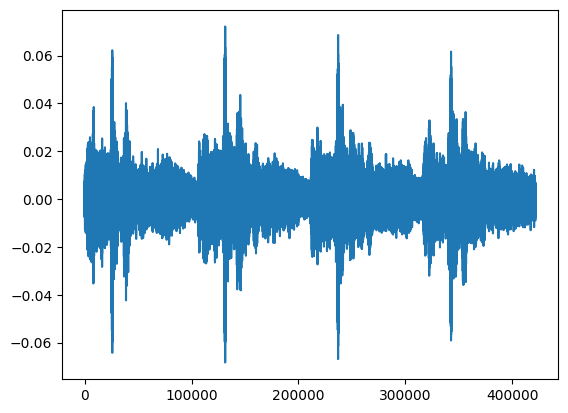

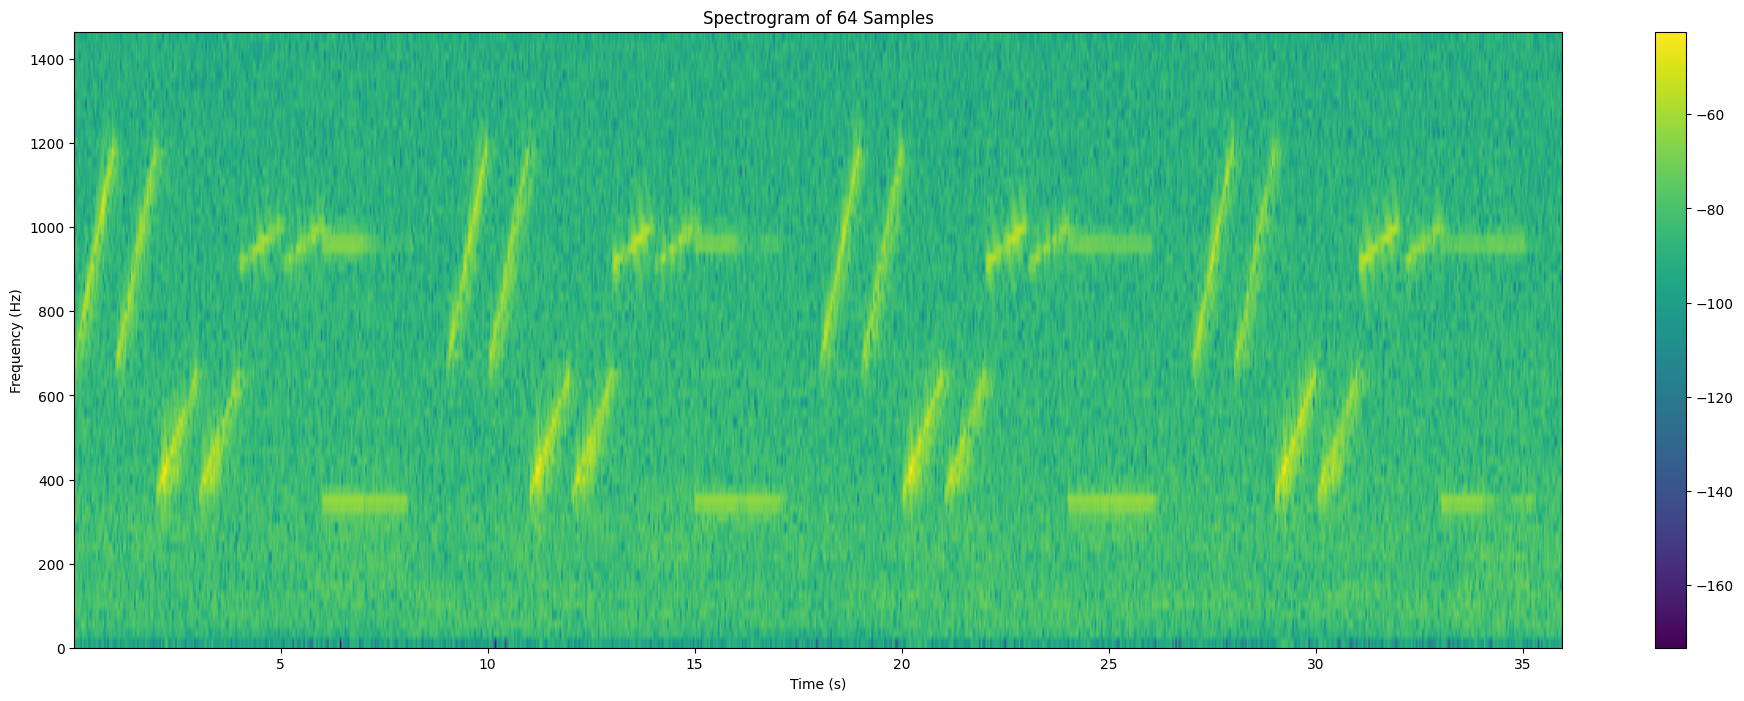

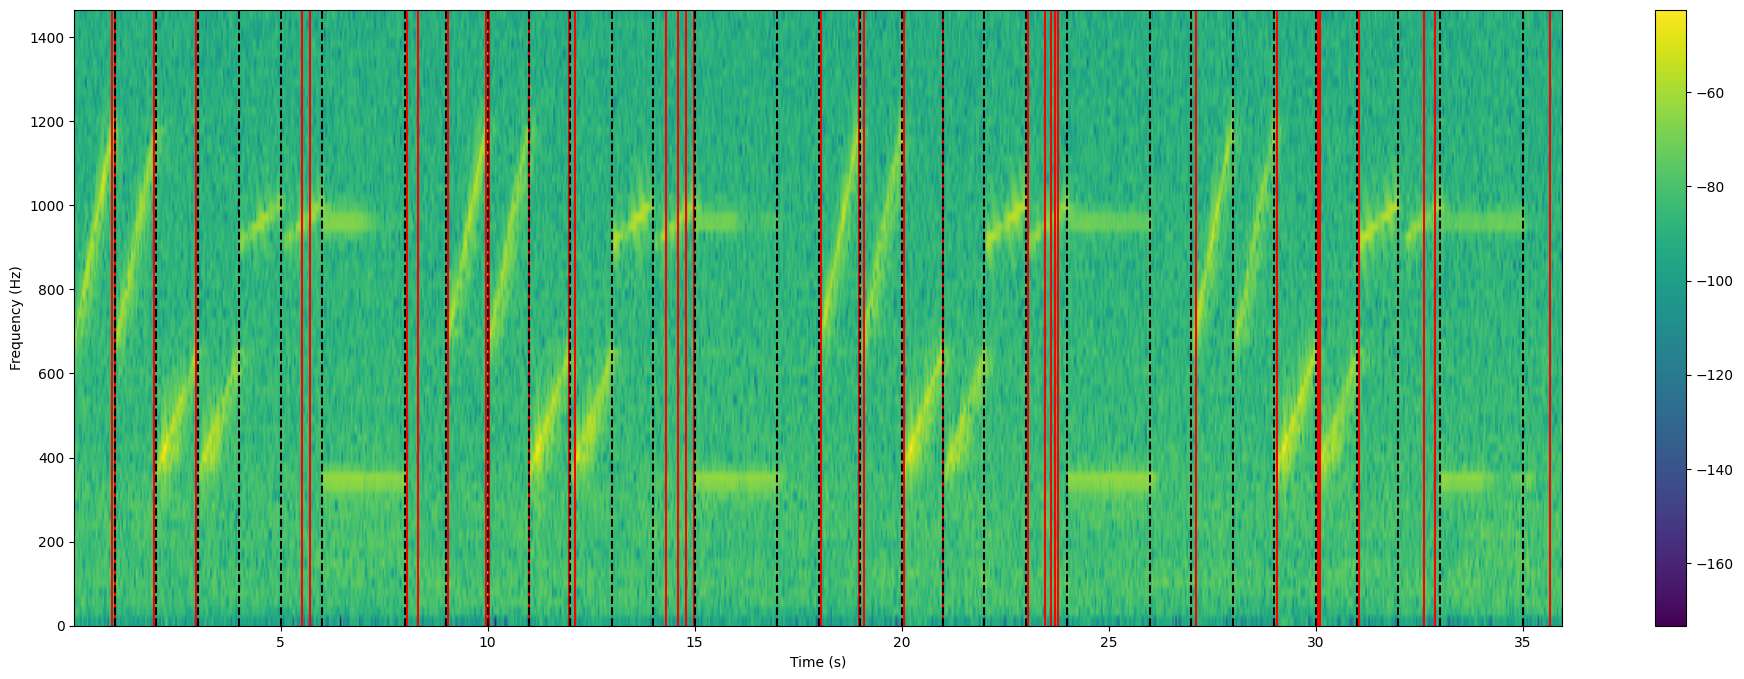

In [ ]:
seclen = t.shape[0] / n_samples
F = f.shape[0] // 4
fig, ax = plt.subplots(figsize=(24,8))
plt.imshow(
    10*np.log10(Sxx[:F,:]), 
    aspect='auto', origin='lower', 
    extent=[t[0], t[-1], f[0], f[F]], 
    cmap='viridis')
plt.colorbar()
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
#plt.vlines([i for i in range(1, 64)], ymin=f[0], ymax=f[F], color='black', linestyle="--")
plt.title("Spectrogram of 64 Samples")
plt.savefig("spectrogram.pdf", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(24,8))
dists = [np.sqrt(ot.emd2_1d(f,f,distributions[:,i],distributions[:,i+1])) for i in range(distributions.shape[1] - 1)]
times = np.linspace(0, n_samples, len(dists))
#plt.pcolormesh(t, f[:F], 10*np.log10(Sxx[:F,:]), shading='gouraud')
plt.imshow(
    10*np.log10(Sxx[:F,:]), 
    aspect='auto', origin='lower', 
    extent=[t[0], t[-1], f[0], f[F]], 
    cmap='viridis')
plt.colorbar()
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
n_changes = n_samples
changes = np.argsort(dists)[-n_changes:][::-1]
plt.vlines(times[changes], color='red',ymin=f[0], ymax=f[F])
plt.vlines([i for i in range(1, n_samples) if i%9!=7], ymin=f[0], ymax=f[F], color='black', linestyle="--")
plt.savefig("spectrogram-with-cps.pdf", bbox_inches="tight")

In [8]:
n_changes / len(dists)

0.03829787234042553

(0.5138888888888888,
 0.5967741935483871,
 0.16666666666666666,
 0.6944444444444444,
 0.1935483870967742,
 0.8064516129032258)

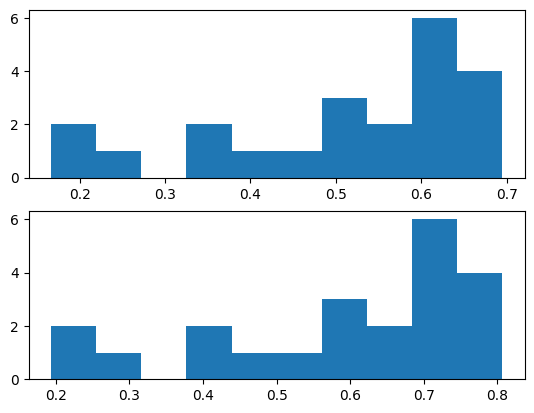

In [44]:
cps = np.sort(w*changes)
gt_sec = np.array([t for t in range(1, n_samples) if t%9 !=7])
gt_samp = fs*gt_sec
dist2min = (1/w)*np.array([np.min(np.abs(cp - gt_samp)) for cp in cps])

np.sort(cps), np.sort(gt_samp), dist2min
np.min(dist2min), np.max(dist2min), np.mean(dist2min)
np.quantile(dist2min, q=0.2), np.quantile(dist2min, q=0.8)

def true_positives(ground_truth, change_points, tol):
    tp = 0
    for t in ground_truth:
        if np.min(np.abs(t - change_points)) < tol:
            tp += 1
    return tp


tps = [true_positives(gt_samp, cps, k) for k in range(3*w, 25*w, w)]
precision = [tp / len(cps) for tp in tps]
recall = [tp / len(gt_samp) for tp in tps]
np.mean(precision), np.mean(recall)
fig, (ax0, ax1) = plt.subplots(2,1)
ax0.hist(precision)
ax1.hist(recall)
np.mean(precision), np.mean(recall), precision[0], precision[-1], recall[0], recall[-1]

In [39]:
len(gt_samp), len(cps)

(31, 36)

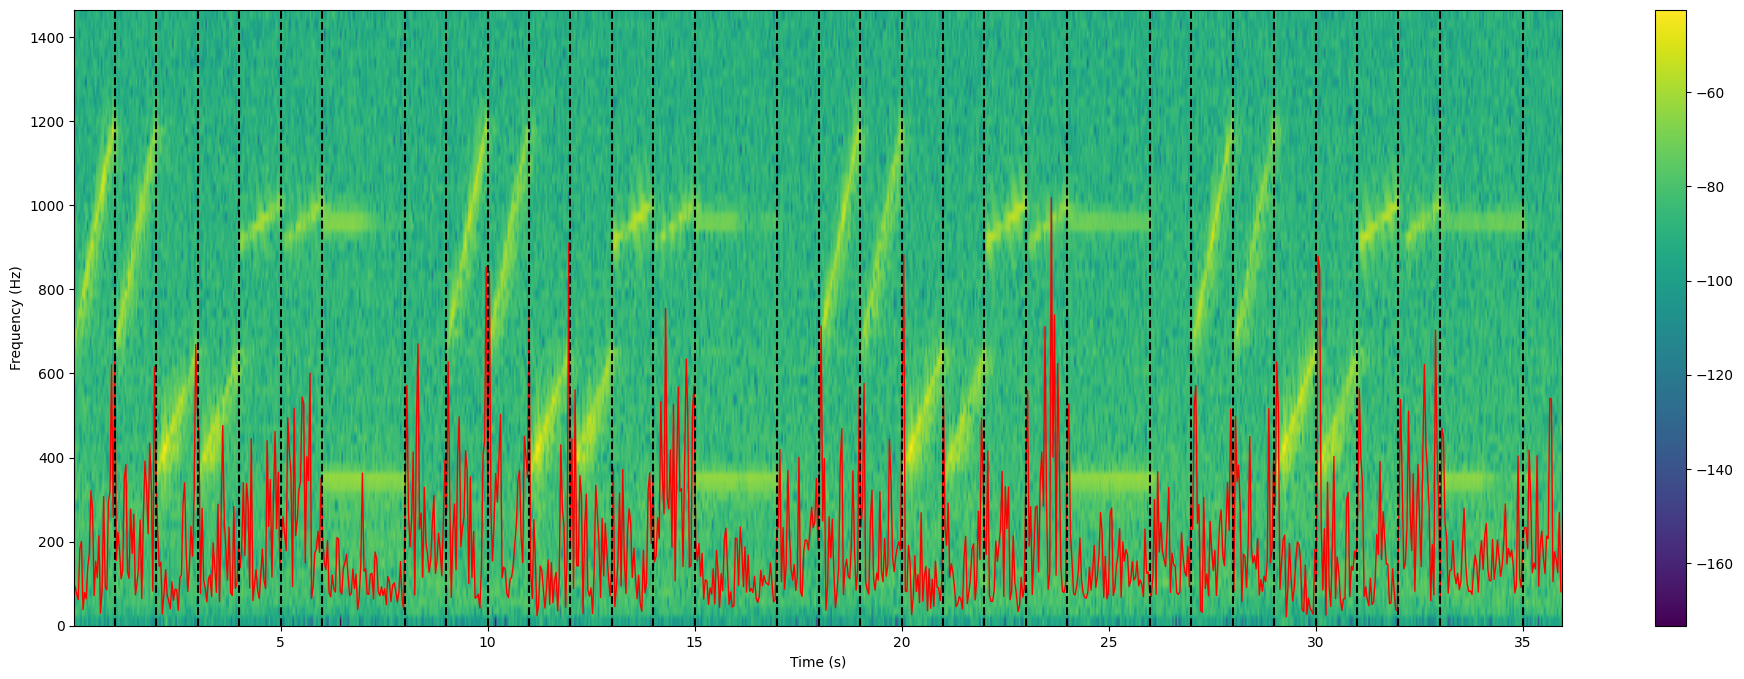

In [216]:
fig, ax = plt.subplots(figsize=(24,8))
dists = [np.sqrt(ot.emd2_1d(f,f,distributions[:,i],distributions[:,i+1])) for i in range(distributions.shape[1] - 1)]
times = np.linspace(0, n_samples, len(dists))
#plt.pcolormesh(t, f[:F], 10*np.log10(Sxx[:F,:]), shading='gouraud')
plt.imshow(
    10*np.log10(Sxx[:F,:]), 
    aspect='auto', origin='lower', 
    extent=[t[0], t[-1], f[0], f[F]], 
    cmap='viridis')
plt.colorbar()
plt.plot(times[1:-2], dists[1:-2], color='red', linewidth=1, linestyle='-')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
changes = np.argsort(dists)[-n_changes:][::-1]
plt.vlines([i for i in range(1, n_samples) if i%9 !=7], ymin=f[0], ymax=f[F], color='black', linestyle="--")
plt.savefig("spec-with-otdist.pdf", bbox_inches="tight")

In [219]:
len(dists)

940

In [107]:
def identify_change_points(X, q):
    """
    Compute change points for the time series X using windowsize w

    Parameters
    ----------
    X: array-like,
       time series data
    q: float, 0 < q < 1
       quantile determining cutoff for change point candidates

    Returns
    -------
    change_points
        boolean array, with entries corresponding to whether
        or not a change occured
    """
    grad = np.gradient(X)
    cutoff = np.quantile(X, q)
    candidates = np.where(X > cutoff)[0]

    in_sequence = False
    N = candidates.shape[0]
    seq_start = 0
    changes = [0]

    for n in range(N - 1):
        curr = candidates[n]
        nx = candidates[n + 1]

        if not in_sequence and nx - curr == 1:
            in_sequence = True
            seq_start = curr

        if (in_sequence and nx - curr > 1) or n == N - 1:
            in_sequence = False
            seq_end = curr
            sequence = grad[seq_start:seq_end]
            changes.append(np.argmin(sequence) + seq_start)
            changes.append(np.argmax(sequence) + seq_start)

    changes.append(X.shape[0] - 1)
    return np.sort(np.unique(changes))
